# Figure7

In [17]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure7")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [18]:
import numbers

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from functions.load_data import loadTrials, loadTrialsM, human_generalization_sessions
from functions.utils import index_in, split_with_image, pairwise_euclid_nan
from functions.decoding import load_feature_mat, image_basenames, pca_standardize, fit_logistic
from functions.plotting import set_paper_theme

set_paper_theme(unicode_minus=False)


### Human data

In [19]:
task_names = ["Animate vs. Inanimate","Natural vs. Artificial","Mammal vs. Non-mammal","Tools vs. Electronics","Human vs. Monkey","Monkey vs. Mammal",
             "Animate vs. Inanimate(THINGS)","Natural vs. Artificial(THINGS)","Mammal vs. Non-mammal(THINGS)","Tools vs. Electronics(THINGS)",
             "Outdoor vs. Indoor","Big vs. Small(THINGS)","Big vs. Small(Konkle)","Fire related vs. Water related(THINGS)","Eastern vs. Western"]

df = human_generalization_sessions()

In [20]:

human_data = []
for task in task_names:
    df_task = df[df["task_label"] == task]

    print(f"{task}")
    subj_data = []
    for i in range(len(df_task)):
        session = df_task.iloc[i]
        subj = session["subject"]
        datafile = f"data_behavior/Human/{session['task']}/{session['filename']}"

        trials = loadTrials(datafile)
        _trials_gen = [tr for tr in trials if tr["trial_type"]=="gen" ]

        utrials,uimages = split_with_image(_trials_gen)
        trials_gen = [_trials[0] for _trials in utrials]
        print(subj,len(uimages))
        choices_gen = np.array([trial["targ_cat"][trial["response"]-1].lower()
            if "targ_cat" in trial else trial["targ_category"][trial["response"]-1]
            for trial in trials_gen])
        choices_gen = [cat.strip().lower() for cat in choices_gen]
        subj_data.append(list(zip(uimages,choices_gen)))
    human_data.append(subj_data)


Animate vs. Inanimate
050 96
060 96
064 96
068 96
069 87
070 96
072 96
073 96
078 96
Natural vs. Artificial
050 80
060 80
064 80
068 80
069 80
070 80
072 80
073 80
078 80
Mammal vs. Non-mammal
050 60
060 60
064 60
068 60
069 60
071 60
072 60
073 60
078 60
Tools vs. Electronics
050 70
060 70
064 70
068 70
069 70
071 70
072 70
073 70
078 70
Human vs. Monkey
050 20
060 20
064 20
068 20
069 20
070 20
072 20
073 20
078 20
Monkey vs. Mammal
050 40
060 40
064 40
068 40
069 40
070 40
072 40
073 40
078 40
Animate vs. Inanimate(THINGS)
048 100
050 100
058 100
060 100
062 100
064 100
065 100
066 100
069 100
Natural vs. Artificial(THINGS)
048 100
050 100
058 100
059 100
060 100
061 100
062 100
063 100
064 100
Mammal vs. Non-mammal(THINGS)
048 100
050 100
058 100
059 100
060 100
061 100
062 100
064 100
066 98
Tools vs. Electronics(THINGS)
048 100
050 100
058 100
059 100
060 100
061 100
062 100
063 100
064 100
Outdoor vs. Indoor
048 120
050 120
058 120
060 120
062 120
063 120
064 120
065 120
066 120

### Monkey data

In [21]:
task_names = ["animate_vs_inanimate_gen","natural_vs_artificial_gen","mammal_vs_reptile_gen","electronics_vs_tools_gen","human_vs_monkey_gen","monkey_vs_mammal_gen",
             "Large_animate_vs_inanimate","Large_natural_vs_artificial","Large_mammal_vs_nonmammal","electronics_vs_tools_THINGS_gen",
             "outdoor_vs_indoor_gen","big_vs_small_gen","big_vs_small_Konkle_gen","fire related_vs_water related_gen","eastern_vs_western_gen"]

In [22]:

monkey_data = []
for task in task_names:
    subj_data = []
    print(f"{task}")
    for monkey in ["Elsa","Judy","Olaf"]:
        trials,_ = loadTrialsM(task,monkey)
        _trials_gen = [trial for trial in trials if trial["trial_type"]=="gen"]

        utrials,uimages = split_with_image(_trials_gen)
        print(monkey,len(uimages))
        trials_gen = [_trials[0] for _trials in utrials]

        choices_gen = np.array([trial["targ_cat"][trial["response"]-1]
            if "targ_cat" in trial else trial["targ_category"][trial["response"]-1]
            for trial in trials_gen])
        choices_gen = [cat.strip().lower() for cat in choices_gen]

        subj_data.append(list(zip(uimages,choices_gen)))
    monkey_data.append(subj_data)


animate_vs_inanimate_gen
Elsa 96
Judy 96
Olaf 96
natural_vs_artificial_gen
Elsa 80
Judy 80
Olaf 80
mammal_vs_reptile_gen
Elsa 60
Judy 60
Olaf 60
electronics_vs_tools_gen
Elsa 70
Judy 70
Olaf 70
human_vs_monkey_gen
Elsa 20
Judy 20
Olaf 20
monkey_vs_mammal_gen
Elsa 40
Judy 40
Olaf 40
Large_animate_vs_inanimate
Elsa 3583
Judy 3583
Olaf 3583
Large_natural_vs_artificial
Elsa 1815
Judy 1815
Olaf 1815
Large_mammal_vs_nonmammal
Elsa 1568
Judy 1568
Olaf 1568
electronics_vs_tools_THINGS_gen
Elsa 100
Judy 100
Olaf 100
outdoor_vs_indoor_gen
Elsa 120
Judy 120
Olaf 120
big_vs_small_gen
Elsa 100
Judy 100
Olaf 100
big_vs_small_Konkle_gen
Elsa 100
Judy 100
Olaf 100
fire related_vs_water related_gen
Elsa 92
Judy 92
Olaf 92
eastern_vs_western_gen
Elsa 100
Judy 100
Olaf 100


### Model data

In [23]:
task_names = ["animate_vs_inanimate","natural_vs_artificial","mammal_vs_reptile","electronics_vs_tools","human_vs_monkey","monkey_vs_mammal",
             "animate_vs_inanimate_THINGS","natural_vs_artificial_THINGS","mammal_vs_nonmammal_THINGS","electronics_vs_tools_THINGS",
             "outdoor_vs_indoor","big_vs_small","big_vs_small_Konkle","fire related_vs_water related","eastern_vs_western"]


models = ["v1_like","LUV","gistSF","texture","alexnet","vgg16","resnet50","vit_b_32","dino_vitb","clip","siglip2"]

In [24]:

model_data = []
task_category = []
for task in task_names:
    _model_data = []
    for model_name in models:
        feature_main = f"data_model/smalltask_features/{task}_{model_name}.mat"
        feature_gen = f"data_model/smalltask_features/{task}_gen_{model_name}.mat"

        x_main, category_main, _ = load_feature_mat(feature_main)
        category_main = [cat.strip().lower() for cat in category_main]

        x_gen, category_gen, fnames_gen = load_feature_mat(feature_gen)
        category_gen = [cat.strip().lower() for cat in category_gen]
        fnames_gen = image_basenames(fnames_gen)

        x_main, x_gen = pca_standardize(x_main, x_gen)

        model = fit_logistic(x_main, category_main)
        pred = model.predict_proba(x_gen)[:,1]

        _model_data.append(list(zip(fnames_gen,pred)))
    task_category.append(model.classes_)
    model_data.append(_model_data)


### Transform data

In [25]:
# data
human_data_T = [list(row) for row in zip(*human_data  )]
monkey_data_T = [list(row) for row in zip(*monkey_data)]
model_data_T = [list(row) for row in zip(*model_data)]
all_data_T = human_data_T + model_data_T + monkey_data_T

## Panel A — Dissimilarity matrix: preparation

In [26]:
name_list =  [f"subj{i}" for i in range(9)] + models + ["Elsa","Judy","Olaf"]

In [59]:

choices = []
for n,task_name in enumerate(task_names):
    task_data = [data[n] for data in all_data_T]

    image = [item[0] for item in task_data[9]]
    category = task_category[n]
    subj = name_list
    choice = np.full((len(image), len(subj)), np.nan)

    for i,subj_data in enumerate(task_data):
        data_dict = dict(subj_data)
        for j,im in enumerate(image):
            if im in data_dict:
                if isinstance(data_dict[im], numbers.Number):
                    choice[j,i] = data_dict[im]
                else:
                    if index_in([data_dict[im]],category)[0]==-1:
                        print('missing1', task_name,name_list[i],j,im,[data_dict[im]],category)
                    choice[j,i] = index_in([data_dict[im]],category)[0]
            else:
                print('missing2', task_name,name_list[i],j,im)
    choices.append(choice)
choices = np.concatenate(choices,axis=0)


missing2 animate_vs_inanimate subj4 25 010205401072.png
missing2 animate_vs_inanimate subj4 41 010405301434.png
missing2 animate_vs_inanimate subj4 43 010409401464.png
missing2 animate_vs_inanimate subj4 53 010705000073.png
missing2 animate_vs_inanimate subj4 66 010505800301.png
missing2 animate_vs_inanimate subj4 71 010511000402.png
missing2 animate_vs_inanimate subj4 77 010605101279.png
missing2 animate_vs_inanimate subj4 90 010806201728.png
missing2 animate_vs_inanimate subj4 95 010811201943.png
missing2 mammal_vs_nonmammal_THINGS subj8 24 kangaroo_14n.png
missing2 mammal_vs_nonmammal_THINGS subj8 37 porcupine_12s.png


In [28]:
human_choice = np.nanmean(choices[:,:9],axis=1)
monkey_choice = np.nanmean(choices[:,-3:],axis=1)

N = 2 + len(models)
all_choice = np.full((choices.shape[0],N),np.nan)
all_choice[:,:4] = choices[:,9:13]
all_choice[:,4] = monkey_choice
all_choice[:,5:12] = choices[:,13:20]
all_choice[:,12] = human_choice
all_choice.shape

(1278, 13)

In [29]:
RDM = pairwise_euclid_nan(all_choice)
RDM.shape

(13, 13)

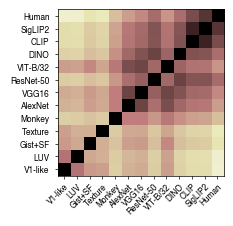

In [30]:
label_list = ["V1-like","LUV","Gist+SF","Texture","Monkey",
"AlexNet","VGG16","ResNet-50","VIT-B/32","DINO","CLIP","SigLIP2","Human"]

# Display the zero diagonal in black using NaN and cmap.set_bad; match the MATLAB pink colormap.
rdm_plot = RDM.astype(float).copy()
np.fill_diagonal(rdm_plot, np.nan)

cmap = plt.colormaps["pink"].copy()
cmap.set_bad("#000000")

n = len(label_list)
fig, ax = plt.subplots(constrained_layout=False)
fig.set_size_inches(160 / 72, 160 / 72)
im = ax.imshow(
    rdm_plot,
    vmin=4,
    vmax=20,
    cmap=cmap,
    interpolation="nearest",
    origin="lower",
)

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(label_list, rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticklabels(label_list)
ax.tick_params(axis="both", which="major", length=2.5, width=0.5, colors="black")
ax.tick_params(axis="x", pad=2)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_edgecolor("black")

ax.set_aspect("equal", adjustable="box")


fig.subplots_adjust(left=0.25, right=0.95, top=0.95, bottom=0.2)

plt.savefig(
    FIGURE_OUTPUT_DIR / "choice_dissimilarity_matrix.pdf",
    pad_inches=0.12,
)
plt.show()


## Panel B — Human and monkey dissimilarity profiles

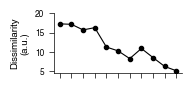

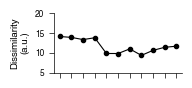

In [31]:
monkey_dis = np.delete(RDM[4, :], [4, -1])
human_dis = np.delete(RDM[-1, :], [4, -1])

label_list = ["V1-like","LUV","Gist+SF","Texture",
"Alexnet","VGG16","ResNet-50","VIT-B/32","DINO","CLIP","SigLIP2"]


# Human
fig, ax = plt.subplots()
fig.set_size_inches(130/ 72, 55 / 72)

x = np.arange(len(models))
ax.plot(x, human_dis, "-o", color="black", linewidth=0.8, markersize=3, label="Human", zorder=2)

ax.set_ylabel("Dissimilarity\n(a.u.)")
ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_yticks([5,10,15,20])

plt.savefig(
    FIGURE_OUTPUT_DIR / "choice_dissimilarity_to_human.pdf",
    pad_inches=0.12,
)
plt.show()

# Monkey
fig, ax = plt.subplots()
fig.set_size_inches(130/ 72, 55 / 72)

x = np.arange(len(models))
ax.plot(x, monkey_dis, "-o", color="black", linewidth=0.8, markersize=3, label="Monkey", zorder=2)

ax.set_ylabel("Dissimilarity\n(a.u.)")
ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_yticks([5,10,15,20])

plt.savefig(
    FIGURE_OUTPUT_DIR / "choice_dissimilarity_to_monkey.pdf",
    pad_inches=0.12,
)
plt.show()

## Panel C — t-SNE

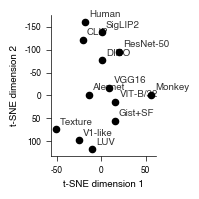

In [58]:
label_list = ["V1-like","LUV","Gist+SF","Texture","Monkey",
"Alexnet","VGG16","ResNet-50","VIT-B/32","DINO","CLIP","SigLIP2","Human"]

# NOTE: with 13 points and perplexity=4 the embedding is extremely
# sensitive to the initialization: neighboring seeds (or ~1e-7 numeric
# input changes) flip it between a spread layout and a degenerate 1-D
# band, and also change the layout's orientation. random_state was
# selected (by sweeping 400 seeds against the published arrangement,
# orientation locked) so the panel reproduces the published figure;
# other seeds land in other basins/orientations.
embedding = TSNE(
    n_components=2,
    metric='precomputed',  # Use the distance/dissimilarity matrix directly.
    init='random',  # PCA initialization is unavailable with precomputed distances.
    random_state=145,
    perplexity=4,
).fit_transform(RDM)


fig, ax = plt.subplots()
fig.set_size_inches(135/ 72, 135 / 72)

ax.scatter(embedding[:, 0], embedding[:, 1], s=20,color="black")
for i, label in enumerate(label_list):
    ax.annotate(label, (embedding[i, 0], embedding[i, 1]), textcoords='offset points', xytext=(3, 2), ha='left', va='bottom', alpha=0.8)


# t-SNE axis directions are arbitrary; flip vertically so Human sits on top
ax.invert_yaxis()

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
# axis limits auto: the manual limits of the previous layout clipped points
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
plt.savefig(
    FIGURE_OUTPUT_DIR / "choice_space_tsne.pdf",
    pad_inches=0.12,
)
plt.show()